# Laboratorium 10 — Seaborn + GridSpec — dashboard analityczny restauracji
**Autor:** Marta Machacka

## Dane startowe

In [ ]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')

# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')

print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

## Ćwiczenie 1: Statystyczne wykresy seaborn

### Zadanie 1.1 — Barplot z hue

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='sex',
    ax=ax,
    palette='muted',
    errorbar=('ci', 95),       # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')

plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")
#tips.groupby('day', observed=True).size()

Pytanie kontrolne: w którym dniu szerokość wąsów (CI) jest największa? Sprawdź tips.groupby('day', observed=True).size() — który dzień ma najmniej obserwacji, i jak wpływa to na precyzję oszacowania średniej?

- najdłuższe wąsy są w piątek (Friday) -> wtedy również występuje najmniej obserwacji. Mniejsza liczba obserwacji powoduje większy błąd standardowy, a więc szerszy przedział ufności i mniejszą precyzję oszacowania średniej.

### Zadanie 1.2 — Boxplot

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data = tips,
    x = 'day',                    # kolumna kategoryczna na oś X (Thur/Fri/Sat/Sun)
    y = 'tip',                    # kolumna numeryczna na oś Y (napiwek)
    hue = 'time',                  # podział kolorystyczny (Lunch/Dinner)
    ax = ax,
    palette = 'pastel',
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')

plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi = 150, bbox_inches = 'tight', facecolor = 'white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

### Zadanie 1.3 — Heatmap korelacji

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

# Korelacja tylko zmiennych numerycznych
corr = tips.select_dtypes('number').corr()

sns.heatmap(
    corr,
    annot = True,                # True — pokaż liczby w komórkach
    fmt = '.2f',                # 2 miejsca po przecinku
    cmap = 'coolwarm',                 # 'coolwarm' — paleta dywergencyjna (czerwony=+, niebieski=-)
    center = 0,               # 0 — środek skali (biały = 0 korelacja)
    ax = ax,
    square = True,
    cbar_kws = {'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji — dataset tips')

plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

### Zadanie 1.4 — Scatter z hue + style

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

tips = sns.load_dataset('tips')
sns.scatterplot(
    data = tips,
    x = 'total_bill',
    y = 'tip',
    hue = 'smoker',      
    style = 'time',      
    alpha = 0.7,         
    ax = ax,
)

ax.set_title('Zależności rachunek↔napiwek')
ax.set_xlabel('kwota rachunku')
ax.set_ylabel('kwota napiwku')

plt.tight_layout()
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

### Zadanie dodatkowe

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

tips = sns.load_dataset('tips')
sns.violinplot(
    data = tips,
    x = 'time',
    y = 'total_bill',
    split = True,
    hue = 'sex',
    palette='pastel',
    ax=ax
)
ax.set_title('Rozkład rachunków Lunch vs Dinner wg płci')
ax.set_xlabel('Pora dnia')
ax.set_ylabel('Rachunek (USD)')

plt.tight_layout()

plt.savefig(
    'violin_total_bill.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

## Ćwiczenie 2: Subplots, GridSpec, shared axes

### Zadanie 2.1 — Regularna siatka 2×2

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# Panel [0, 0] — barplot (gotowy wzór)
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
            ax=axes[0, 0], palette='muted', errorbar=('ci', 95))
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')

# Panel [0, 1] — boxplot (uzupełnij)
sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    hue='day', legend=False,
    ax=axes[0, 1],
    palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')

# Panel [1, 0] — scatter (uzupełnij)
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    alpha=0.7,
    ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')

# Panel [1, 1] — countplot (uzupełnij)
sns.countplot(
    data=tips,
    x='day',
    hue='time',
    ax=axes[1, 1],
    palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')

fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2',
             fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

### Zadanie 2.2 — GridSpec — nieregularny dashboard

In [ ]:
fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Górny — pełna szerokość: barplot suma rachunków per dzień
ax_top = fig.add_subplot(gs[0, :])

tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(
    tips_sum['day'].astype(str),
    tips_sum['total_bill'],
    color=sns.color_palette('muted')[:4],
    edgecolor='white', linewidth=1.2,
)
# Dodaj wartości nad słupkami
for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'${val:.0f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_top.set_title('Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)',
                 fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')

# Dolny lewy — boxplot Lunch vs Dinner (uzupełnij)
ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(
    data=tips,
    x='time',                    # 'time'
    y='tip',                    # 'tip'
    hue='time', legend=False,
    ax=ax_bl,
    palette='pastel',
)
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')

# Dolny prawy — heatmap pivot (samodzielnie)
# Cel: stwórz pivot_table — wiersze=day, kolumny=time, wartości=mean(tip)

# Zwizualizuj jako heatmap z annot=True, fmt='.2f', cmap='YlOrRd'
ax_br = fig.add_subplot(gs[1, 1])
# Twój kod:
pivot = tips.pivot_table(
    values = 'tip',
    index= 'day',
    columns= 'time',
    aggfunc= 'mean'
)

sns.heatmap(
    data = pivot,
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd'

)
ax_br.set_title('Średni napiwek (dzień × pora)')

fig.suptitle('Dashboard GridSpec — górny pełny + 2 dolne',
             fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: gridspec_dashboard.png")

### Zadanie 2.3 — Shared axes

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8),
                         sharex='col', sharey='row',
                         constrained_layout=True)

# Twój kod — 4 wykresy

# axes[0, 0] stripplot napiwki
sns.stripplot(
    data = tips,
    x = 'day',
    y = 'tip',
    jitter = True, 
    ax = axes[0, 0]
)

# axes[1, 0] boxplot napiwki
sns.boxplot(
    data = tips,
    x = 'day',
    y = 'tip',
    ax = axes[1, 0]

)

# axes[0, 1] stripplot rachunki
sns.stripplot(
    data = tips,
    x = 'day',
    y = 'total_bill',
    ax = axes[0,1]
)

# axes[1, 1] boxplot rachunki
sns.boxplot(
    data = tips,
    x = 'day',
    y = 'total_bill',
    ax = axes[1,1]
)

for ax in axes[:, 0]:
    ax.set_ylabel('tip')
    ax.yaxis.label.set_visible(True)

for ax in axes[:, 1]:
    ax.set_ylabel('total bill')
    ax.yaxis.label.set_visible(True)

fig.suptitle('Strip + Box plot — porównanie dwóch widoków',
             fontsize=14, 
             fontweight='bold')

plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

## Ćwiczenie 3: Pełny dashboard analityczny

**Cel: Zaprojektować i zbudować kompletny dashboard 6-panelowy odpowiadający na pytania właściciela restauracji.**

Scenariusz biznesowy: Właściciel restauracji „Pod Widelcem" formułuje pytania analityczne:

„Jak idzie biznes? Kiedy zarabiamy najwięcej? Kto zostawia największe napiwki? Czy istnieją zależności między zmiennymi?"

**Wymagane:** spójna narracja dashboardu — sześć paneli ma odpowiadać na powyższe pytania, nie być przypadkowym zestawieniem wykresów. Reguła: dashboard = jedna figura, wiele wykresów, jedna historia.

### Zadanie 3.1 — Projekt dashboardu

Przed napisaniem kodu określ:
1. Pytanie główne (KPI): w którym dniu restauracja zarabia najwięcej? → 1 panel duży (górny, pełna szerokość lub 2/3)
2. 3-4 panele pomocnicze: rozkład napiwków, korelacja zmiennych, scatter rachunek↔napiwek, proporcja dni (pie/countplot)
3. 1 panel sumaryczny (dolny, pełna szerokość): rozkład rachunków per dzień (violinplot)

Określenie układu paneli przed implementacją skraca czas iteracji nad rozmieszczeniem.

### Zadanie 3.2 — Implementacja dashboardu

In [ ]:
# Restaurant Analytics Dashboard "Pod Widelcem"
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')   # tło figury — jasnoszare

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

sns.set_palette('muted')
# === PANEL 1 (KPI główny): łączne przychody per dzień (gs[0, :2]) ===
ax1 = fig.add_subplot(gs[0, :2])
# Twój kod — barplot z etykietami wartości nad słupkami
przychody_per_dzien = tips.groupby('day', observed = True)['total_bill'].sum()
sns.barplot(
    x = przychody_per_dzien.index,
    y = przychody_per_dzien.values,
    ax = ax1
)

for i, value in enumerate(przychody_per_dzien.values):
    ax1.text(
        i,
        value + 5,
        f'{value:.0f}',
        ha='center',
        fontweight='bold'

    )

ax1.set_title('Łączne przychody per dzień', fontweight = 'bold')
ax1.set_xlabel('Dzień')
ax1.set_ylabel('Przychody ($)')

# === PANEL 2: udział wizyt per dzień (gs[0, 2]) ===
ax2 = fig.add_subplot(gs[0, 2])
# Twój kod — pie chart lub countplot
wizyty_per_dzien = tips['day'].value_counts()
ax2.pie(
    wizyty_per_dzien.values,
    labels= wizyty_per_dzien.index,
    autopct='%1.1f%%'
)
ax2.set_title('Udział wizyt per dzień', fontweight = 'bold')

# === PANEL 3: rozkład napiwków (gs[1, 0]) ===
ax3 = fig.add_subplot(gs[1, 0])
# Twój kod — boxplot napiwki per dzień
sns.boxplot(
    data = tips,
    x = 'day',
    y = 'tip',
    ax = ax3
)

ax3.set_title('Rozkład napiwków', fontweight = 'bold')
ax3.set_xlabel('Dzień')
ax3.set_ylabel('Napiwki ($)')

# === PANEL 4: heatmap korelacji (gs[1, 1]) ===
ax4 = fig.add_subplot(gs[1, 1])
# Twój kod — sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
corr = tips[['total_bill', 'tip', 'size']].corr()
corr.index = ['Rachunek', 'Napiwek', 'Il. osób']
corr.columns = ['Rachunek', 'Napiwek', 'Il. osób']
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask = mask,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    ax = ax4)

ax4.set_title('Heatmapa korelacji', fontweight = 'bold')
ax4.set_xlabel('Zmienne')
ax4.set_ylabel('Zmienne')

# === PANEL 5: scatter (gs[1, 2]) ===
ax5 = fig.add_subplot(gs[1, 2])
# Twój kod — sns.scatterplot rachunek vs napiwek z hue='smoker'
sns.scatterplot(
    data = tips,
    x = 'total_bill',
    y = 'tip',
    hue = 'smoker',
    ax = ax5
)

ax5.set_title('Rachunek vs napiwek', fontweight = 'bold')
ax5.set_xlabel('Rachunek')
ax5.set_ylabel('Napiwek')

handles, labels = ax5.get_legend_handles_labels()
ax5.legend(
    handles,
    ['Tak', 'Nie'],
    title='Palacz'
)

# === PANEL 6 (sumaryczny): rozkład rachunków (gs[2, :]) ===
ax6 = fig.add_subplot(gs[2, :])
# Twój kod — sns.violinplot rachunki per dzień z hue='time', split=True
sns.violinplot(
    data = tips,
    x = 'day',
    y = 'total_bill',
    hue = 'time',
    split = True,
    ax = ax6
)

ax6.set_title('Sumaryczny rozkład rachunków', fontweight = 'bold')
ax6.set_xlabel('Dzień')
ax6.set_ylabel('Rachunek')

ax6.legend(
    title='Pora dnia',

)

fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('dashboard_pod_widelcem.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: dashboard_pod_widelcem.png")

### Zadanie 3.3 — Wnioski biznesowe

Najbardziej dochodowym dniem jest sobota, a wysoki przychód utrzymuje się także w niedzielę, co wskazuje na dominującą rolę weekendu w generowaniu zysków. 
Występuje umiarkowana dodatnia korelacja między wysokością rachunku a napiwkiem (około 0.6–0.7), co oznacza, że wraz ze wzrostem rachunku napiwek zwykle rośnie. 
Palacze i niepalacze zostawiają napiwki o podobnym poziomie, choć u palaczy widoczna jest większa zmienność. 
Rekomenduję zwiększenie zasobów obsługi w weekendy oraz analizę działań promocyjnych na piątek, który generuje wyraźnie niższe przychody.

## Ćwiczenie 4: Style, eksport, adnotacja

Cel: Profesjonalne wykończenie wykresu (style, palety, adnotacja)

### Zadanie 4.1 — Porównanie stylów seaborn

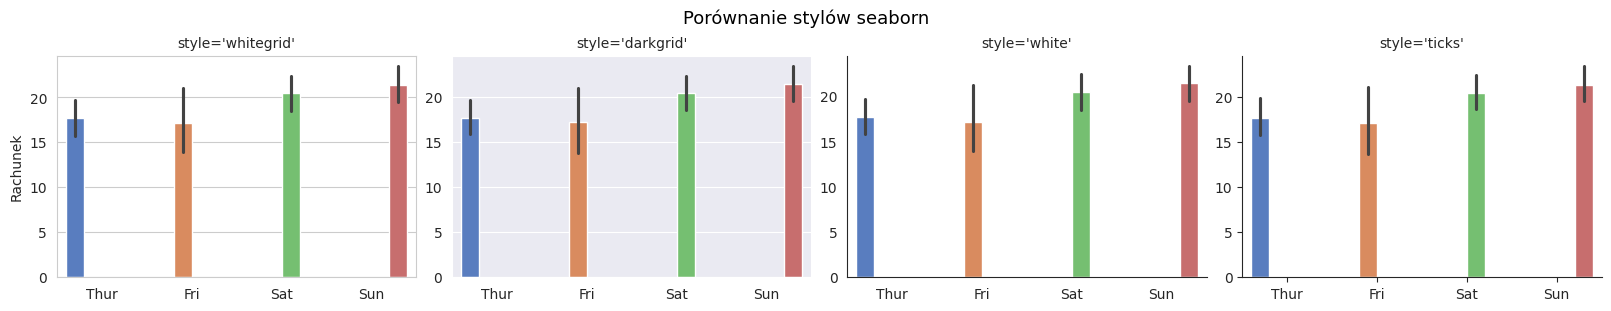

In [11]:
sns.reset_orig()
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']

# Tworzymy samą figurę (bez osi)
fig = plt.figure(figsize=(16, 3), constrained_layout=True)

for i, style in enumerate(styles):
    # KLUCZOWA ZMIANA: Tworzymy oś INSIDE menedżera kontekstu
    with sns.axes_style(style):
        ax = fig.add_subplot(1, 4, i + 1)
        
        sns.barplot(
            data=tips, x='day', y='total_bill', hue='day', legend=False,
            ax=ax, palette='muted'
        )
        
        # Opcjonalne czyszczenie ramek dla stylu 'ticks' lub 'white'
        if style in ['white', 'ticks']:
            sns.despine(ax=ax)
            
        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Rachunek' if i == 0 else '')

fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow_poprawne.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Pytanie kontrolne:** który styl jest odpowiedni do prezentacji zarządczej (slajdy), a który do publikacji naukowej (papier biały)? Odpowiedź w komentarzu w komórce.

Prezentacja zarządcza (slajdy):
- whitegrid (najczęściej, bo siatka ułatwia szybkie odczytanie danych)
- darkgrid (czasem w dashboardach / przy dużym kontraście)

Publikacja naukowa (paper):
- white (czysty, minimalny styl – typowy do publikacji)
- ticks 

### Zadanie 4.2 — Adnotacja na wykresie

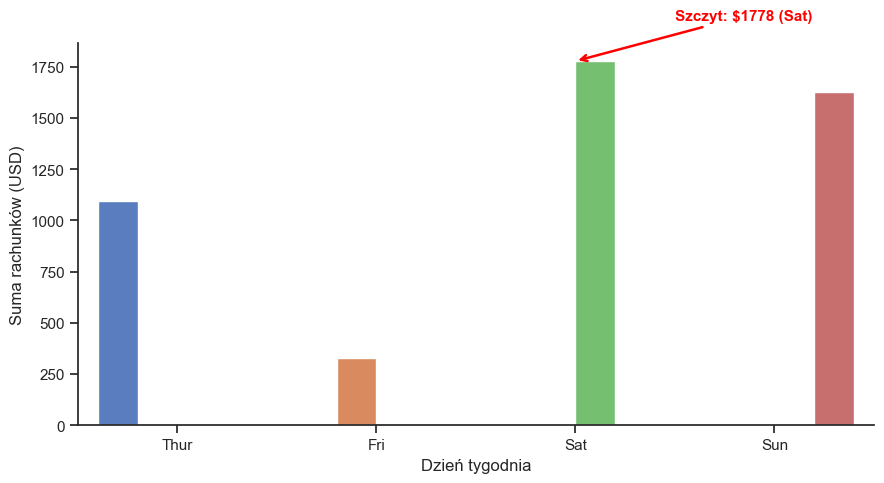

Zapisano: szczyt_przychodow.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False,
            ax=ax, palette='muted')

# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']

# Adnotacja ze strzałką
ax.annotate(
    f'Szczyt: ${max_val:.0f} ({max_day})',
    xy=(max_idx, max_val),                # punkt na który wskazuje strzałka — (max_idx, max_val)
    xytext=(max_idx + 0.5, max_val + 200),            # gdzie tekst — (max_idx + 0.5, max_val + 200)
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    fontsize=11, color='red', fontweight='bold',
)

# Tytuł celowo pominięty — adnotacja 'Szczyt: $...' sama w sobie informuje o czym wykres
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine()                     # usuwa górną i prawą krawędź osi (minimalistyczny styl)

plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")